# Model

### Imports

In [5]:
import sys
import pandas as pd
import numpy as np

### Load Dataset

In [6]:
# Allow the dataset to be loaded with both a Google Colab kernel and a local kernel

# Load the dataset with Google Colab kernel and Drive file
if 'google.colab' in sys.modules:
    from pydrive2.auth import GoogleAuth
    from pydrive2.drive import GoogleDrive
    from google.colab import auth # type: ignore
    from oauth2client.client import GoogleCredentials

    # Authenticate the User in Google Drive
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Google Drive ID for public sharing of the dataset

    # processed_data.csv
    file_id = "1m1_Wq_Pi1eSRtH4Zb0KkjQ-YYQWOTB39"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('processed_data.csv')

    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Load the dataset with local kernel and local file
else:
    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("../data/processed/processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Stop Jupyter Notebook from limiting the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Display dataset head
df.head()

,instant,season,hour,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,day,datetime
0,1,1,0,False,6,False,1,0.24,0.2879,0.81,0.0,3,13,16,2011,1,1,2011-01-01 00:00:00
1,2,1,1,False,6,False,1,0.22,0.2727,0.8,0.0,8,32,40,2011,1,1,2011-01-01 01:00:00
2,3,1,2,False,6,False,1,0.22,0.2727,0.8,0.0,5,27,32,2011,1,1,2011-01-01 02:00:00
3,4,1,3,False,6,False,1,0.24,0.2879,0.75,0.0,3,10,13,2011,1,1,2011-01-01 03:00:00
4,5,1,4,False,6,False,1,0.24,0.2879,0.75,0.0,0,1,1,2011,1,1,2011-01-01 04:00:00


### Time Series Analysis

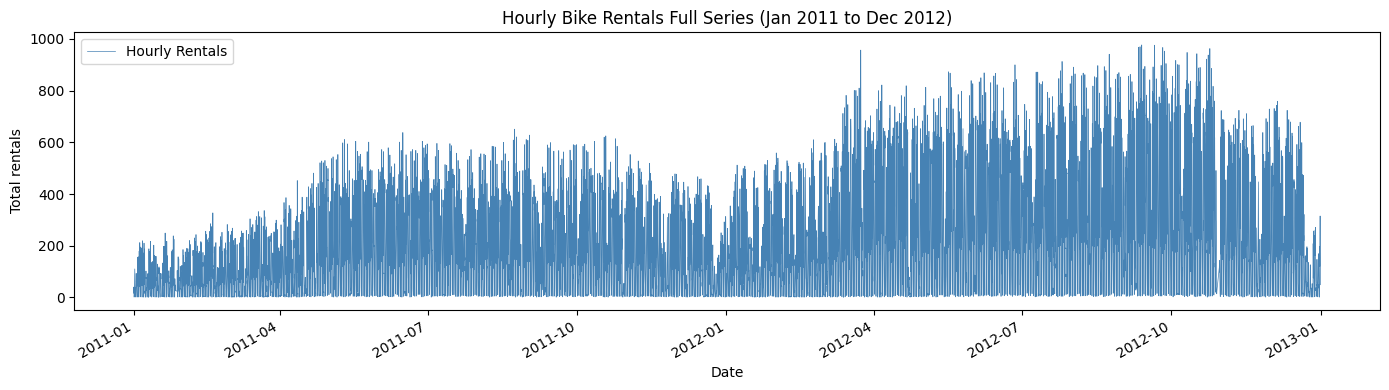

Series length : 17,379 hourly observations
Date range    : 2011-01-01 00:00:00 → 2012-12-31 23:00:00
Min - Max     : 1 - 977


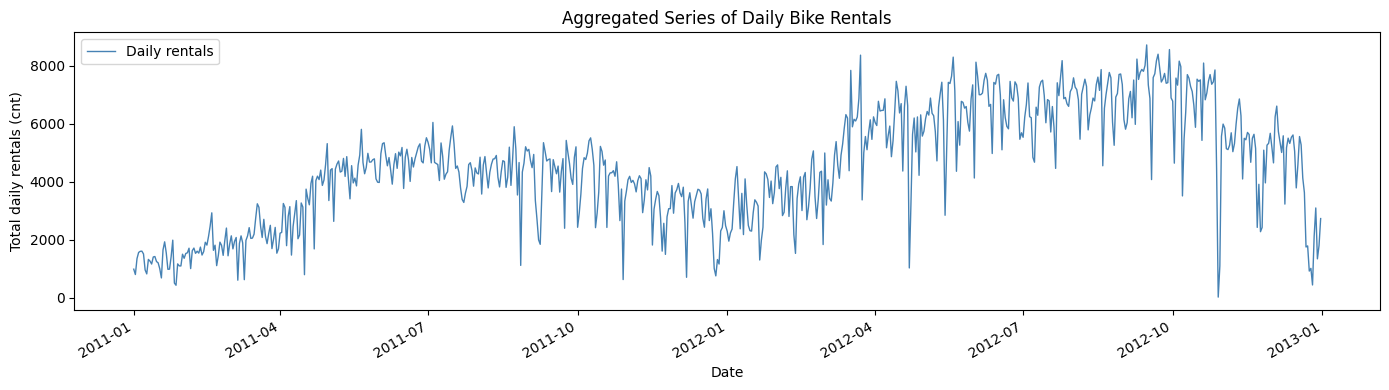


ADF Stationarity Test (Daily Series)
ADF Statistic : -1.8774
p-value       : 0.3427
→ p-value ≥ 0.05: the series is NON-STATIONARY (Differencing Required).


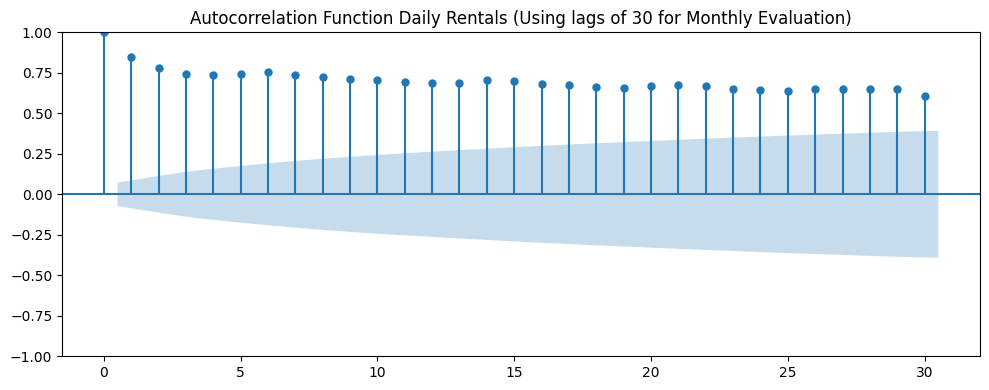

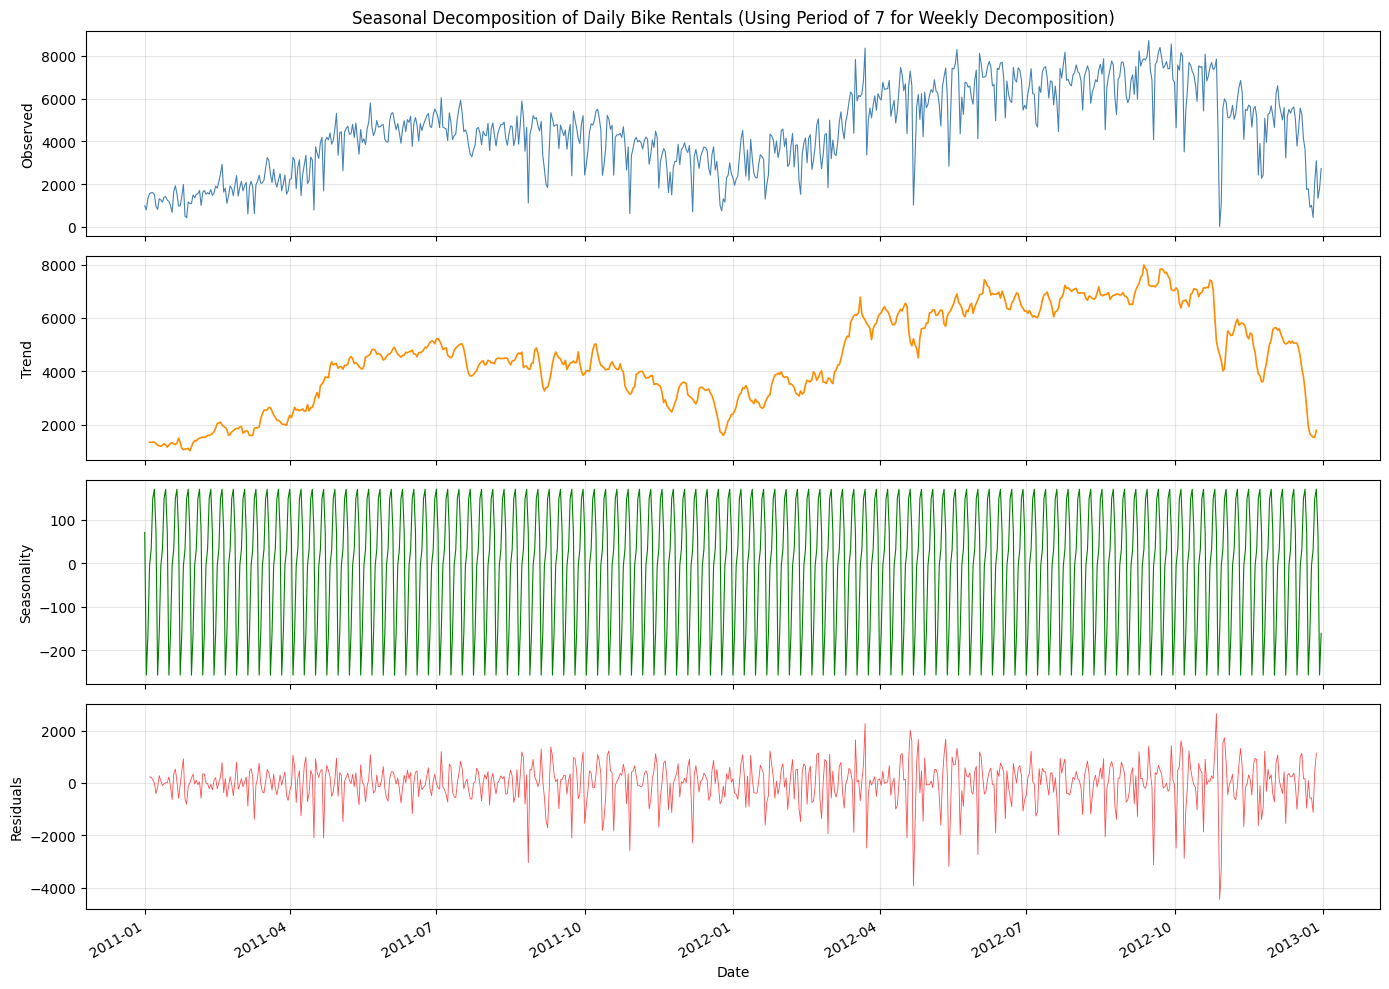

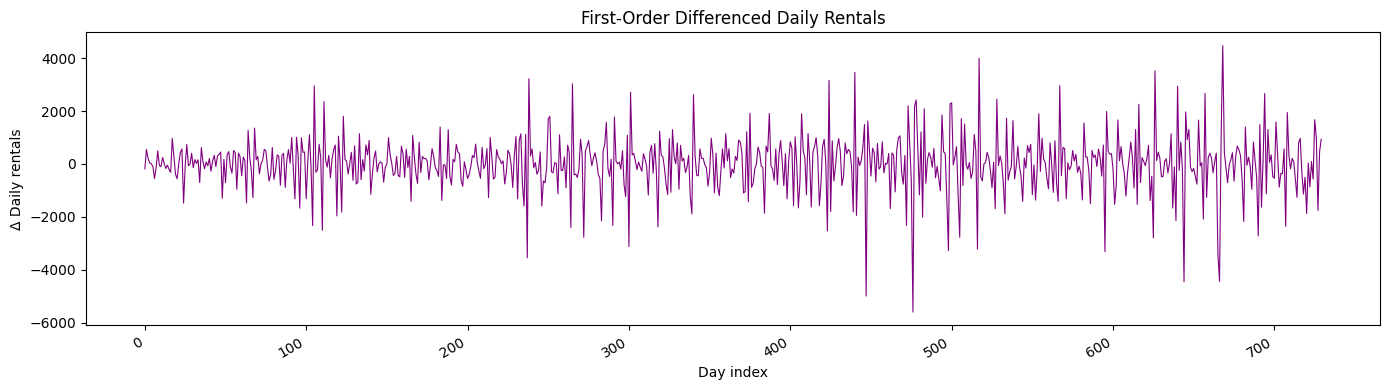


ADF Stationarity Test (Differenced Series):
ADF Statistic : -11.7788
p-value       : 0.0000
→ p-value < 0.05: differenced series is STATIONARY.


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Visualize the hourly Time Series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['datetime'], df['cnt'], linewidth=0.5, color='steelblue', label='Hourly Rentals')
ax.set_xlabel('Date')
ax.set_ylabel('Total rentals')
ax.set_title('Hourly Bike Rentals Full Series (Jan 2011 to Dec 2012)')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Series length : {len(df):,} hourly observations")
print(f"Date range    : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Min - Max     : {df['cnt'].min()} - {df['cnt'].max()}")

# 2. Visualize the aggregation
daily = df.groupby(df['datetime'].dt.date)['cnt'].sum().reset_index()
daily.columns = ['date', 'cnt']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.set_index('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['cnt'], linewidth=1, color='steelblue', label='Daily rentals')
ax.set_xlabel('Date')
ax.set_ylabel('Total daily rentals (cnt)')
ax.set_title('Aggregated Series of Daily Bike Rentals')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 3. ADF test of the Time Series
ADF_result = adfuller(daily['cnt'])
print("\nADF Stationarity Test (Daily Series)")
print(f"ADF Statistic : {ADF_result[0]:.4f}")
print(f"p-value       : {ADF_result[1]:.4f}")
if ADF_result[1] < 0.05:
    print("→ p-value < 0.05: the series is STATIONARY (no unit root).")
else:
    print("→ p-value ≥ 0.05: the series is NON-STATIONARY (Differencing Required).")

# 4. ACF test of the Time Series
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(daily['cnt'], lags=30, ax=ax)
ax.set_title('Autocorrelation Function Daily Rentals (Using lags of 30 for Monthly Evaluation)')
plt.tight_layout()
plt.show()

# 5. Seasonal decomposition of the Time Series
# Period of 7 is used as weekly for the decomposition
decomposition = seasonal_decompose(daily['cnt'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomposition.observed, linewidth=0.8, color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Seasonal Decomposition of Daily Bike Rentals (Using Period of 7 for Weekly Decomposition)')

axes[1].plot(decomposition.trend, linewidth=1.2, color='darkorange')
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal, linewidth=0.8, color='green')
axes[2].set_ylabel('Seasonality')

axes[3].plot(decomposition.resid, linewidth=0.6, color='red', alpha=0.7)
axes[3].set_ylabel('Residuals')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 6. First-order differencing of the Time Series
daily_diff = np.diff(daily['cnt'].values, n=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_diff, linewidth=0.8, color='purple')
ax.set_xlabel('Day index')
ax.set_ylabel('Δ Daily rentals')
ax.set_title('First-Order Differenced Daily Rentals')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

ADF_diff = adfuller(daily_diff)
print("\nADF Stationarity Test (Differenced Series):")
print(f"ADF Statistic : {ADF_diff[0]:.4f}")
print(f"p-value       : {ADF_diff[1]:.4f}")
if ADF_diff[1] < 0.05:
    print("→ p-value < 0.05: differenced series is STATIONARY.")
else:
    print("→ p-value ≥ 0.05: further differencing may be needed.")

### ARMA

### ARIMA

### SARIMA

### AutoArima

### Transformer Based Architecture

### Results Discussion

### Lessons Learned